# Blood Bank Management System - Data Visualization Project

This notebook provides comprehensive data visualizations for the blood donor dataset, including exploratory data analysis, statistical insights, and interactive charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [2]:
# Load the cleaned blood donor dataset
df = pd.read_csv('cleaned_blood_donor_dataset.csv')

# Convert created_at to datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10000, 11)

Columns: ['donor_id', 'name', 'email', 'contact_number', 'city', 'blood_group', 'availability', 'months_since_first_donation', 'number_of_donation', 'pints_donated', 'created_at']

Data Types:
donor_id                               object
name                                   object
email                                  object
contact_number                         object
city                                   object
blood_group                            object
availability                           object
months_since_first_donation             int64
number_of_donation                      int64
pints_donated                           int64
created_at                     datetime64[ns]
dtype: object

First 5 rows:


,donor_id,name,email,contact_number,city,blood_group,availability,months_since_first_donation,number_of_donation,pints_donated,created_at
0,1b8b4c828a,Norma Fisher,ysullivan@yahoo.com,+61 461706749,Hobart,A+,No,65,31,62,2017-03-17
1,a6a3f7fe55,Eugene Bowman,hramos@brown-sellers.com,+61 450709944,Darwin,AB-,Yes,64,8,16,2016-11-11
2,cee6478144,Sheri Bolton DDS,jasmine85@hotmail.com,+61 428756361,Melbourne,AB+,Yes,39,6,6,2022-02-25
3,5986bc55f9,Kelly Boyd,pattylawrence@riley-hayes.com,+61 454318320,Darwin,A-,No,55,20,20,2025-04-04
4,93246afe6c,Taylor Guzman,martinezjacob@wilson.com,+61 484158472,Darwin,O-,No,7,35,35,2022-11-30


In [3]:
# Data Exploration
print("Summary Statistics:")
print(df.describe())

print("\nBlood Group Distribution:")
print(df['blood_group'].value_counts())

print("\nCity Distribution:")
print(df['city'].value_counts())

print("\nAvailability Distribution:")
print(df['availability'].value_counts())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Summary Statistics:
       months_since_first_donation  number_of_donation  pints_donated  \
count                 10000.000000        10000.000000   10000.000000   
mean                     59.953100           25.128200      37.614000   
min                       0.000000            0.000000       0.000000   
25%                      30.000000           12.000000      16.000000   
50%                      60.000000           26.000000      34.000000   
75%                      90.000000           38.000000      50.000000   
max                     120.000000           50.000000     100.000000   
std                      34.911379           14.654195      26.334072   

                       created_at  
count                       10000  
mean   2020-06-28 03:15:33.120000  
min           2015-07-01 00:00:00  
25%           2017-12-25 00:00:00  
50%           2020-07-08 00:00:00  
75%           2022-12-28 00:00:00  
max           2025-06-30 00:00:00  
std                           NaN 

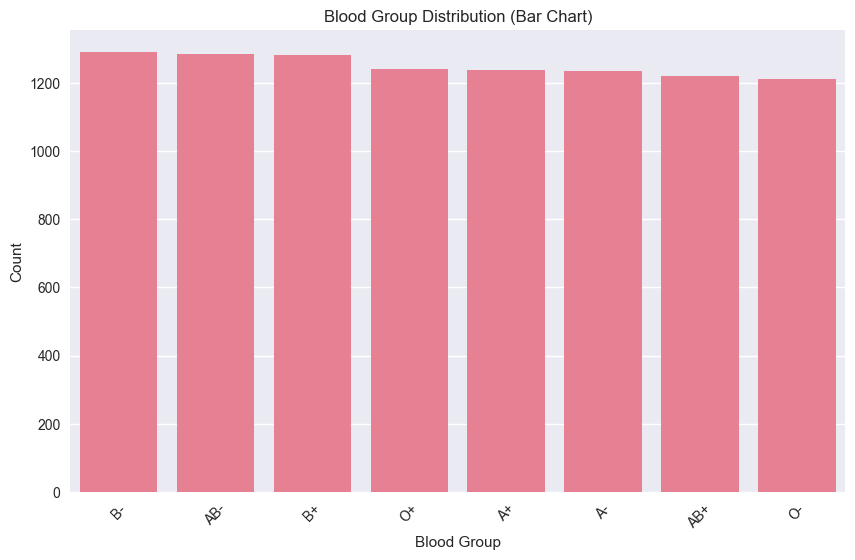

In [3]:
# Blood Group Distribution
fig = px.pie(df, names='blood_group', title='Blood Group Distribution',
             color_discrete_sequence=px.colors.qualitative.Set3)
fig.show()

# Bar chart for blood groups
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='blood_group', order=df['blood_group'].value_counts().index)
plt.title('Blood Group Distribution (Bar Chart)')
plt.xlabel('Blood Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [4]:
# City Distribution
fig = px.bar(df['city'].value_counts(), title='Donor Distribution by City',
             labels={'value': 'Number of Donors', 'index': 'City'})
fig.show()

# Availability Pie Chart
availability_counts = df['availability'].value_counts()
fig = px.pie(values=availability_counts.values, names=availability_counts.index,
             title='Donor Availability', color_discrete_sequence=['#FF9999','#66B2FF'])
fig.show()

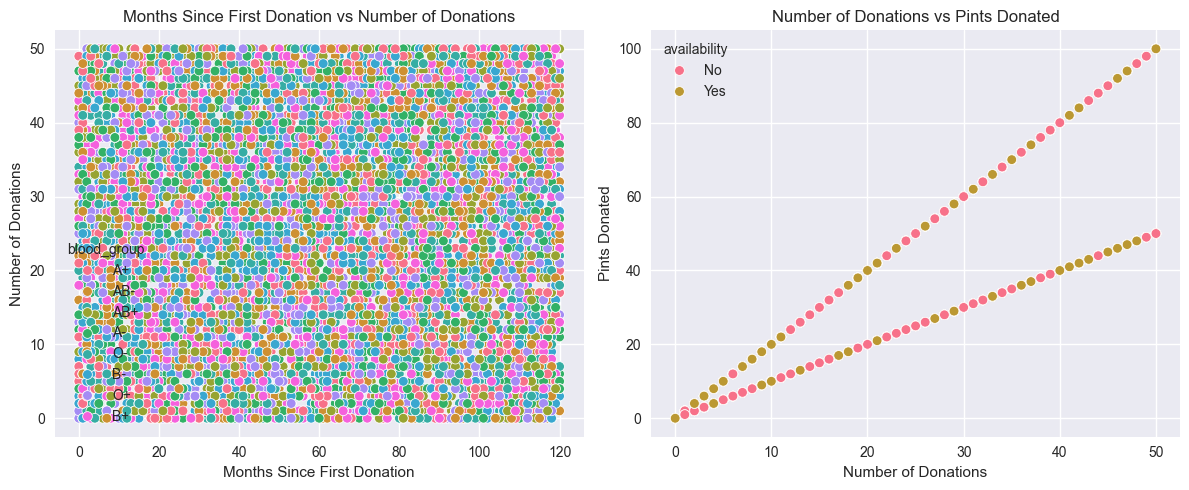

In [5]:
# Donation Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='months_since_first_donation', y='number_of_donation', hue='blood_group')
plt.title('Months Since First Donation vs Number of Donations')
plt.xlabel('Months Since First Donation')
plt.ylabel('Number of Donations')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='number_of_donation', y='pints_donated', hue='availability')
plt.title('Number of Donations vs Pints Donated')
plt.xlabel('Number of Donations')
plt.ylabel('Pints Donated')

plt.tight_layout()
plt.show()

# Total Pints by Blood Group
total_pints = df.groupby('blood_group')['pints_donated'].sum().sort_values(ascending=False)
fig = px.bar(total_pints, title='Total Pints Donated by Blood Group',
             labels={'value': 'Total Pints', 'blood_group': 'Blood Group'})
fig.show()

In [6]:
# Time Series Analysis
df['year'] = df['created_at'].dt.year
donations_per_year = df.groupby('year')['number_of_donation'].sum()

fig = px.line(donations_per_year, title='Total Donations Over Time',
              labels={'value': 'Total Donations', 'year': 'Year'})
fig.show()

# Monthly donations
df['month'] = df['created_at'].dt.month
monthly_donations = df.groupby(['year', 'month'])['number_of_donation'].sum().reset_index()
monthly_donations['date'] = pd.to_datetime(monthly_donations[['year', 'month']].assign(day=1))

fig = px.line(monthly_donations, x='date', y='number_of_donation',
              title='Monthly Donation Trends')
fig.show()

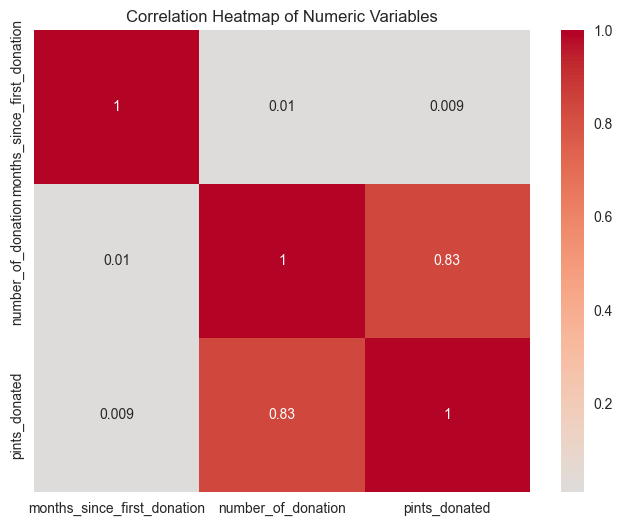

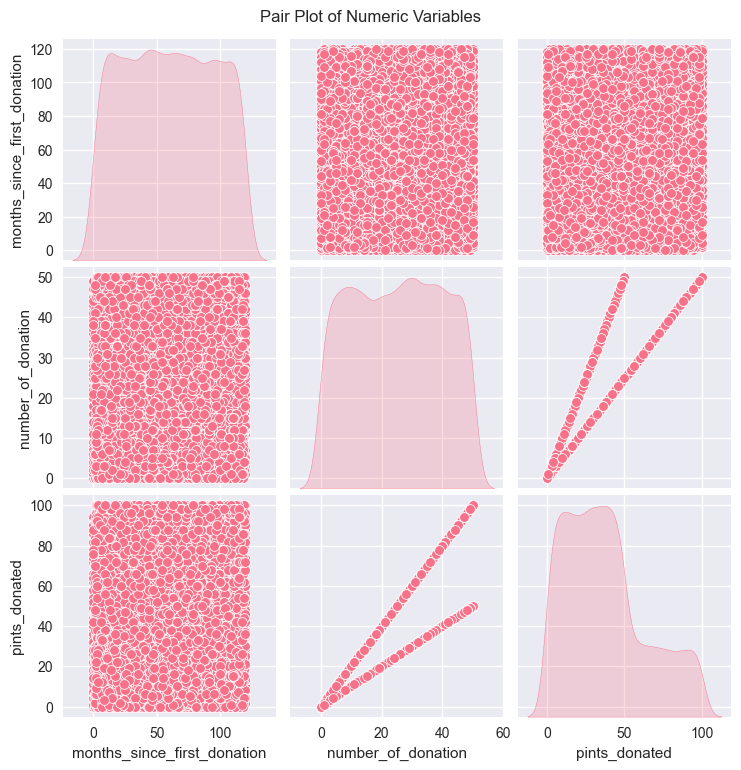

In [7]:
# Correlation Analysis
numeric_cols = ['months_since_first_donation', 'number_of_donation', 'pints_donated']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

# Pair Plot
sns.pairplot(df[numeric_cols], diag_kind='kde')
plt.suptitle('Pair Plot of Numeric Variables', y=1.02)
plt.show()

In [8]:
# Interactive Dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Blood Group Distribution', 'City Distribution',
                    'Availability Status', 'Donation Trends'),
    specs=[[{'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'pie'}, {'type': 'scatter'}]]
)

# Blood Group Pie
blood_group_counts = df['blood_group'].value_counts()
fig.add_trace(go.Pie(labels=blood_group_counts.index, values=blood_group_counts.values,
                     name='Blood Groups'), 1, 1)

# City Bar
city_counts = df['city'].value_counts()
fig.add_trace(go.Bar(x=city_counts.index, y=city_counts.values, name='Cities'), 1, 2)

# Availability Pie
avail_counts = df['availability'].value_counts()
fig.add_trace(go.Pie(labels=avail_counts.index, values=avail_counts.values,
                     name='Availability'), 2, 1)

# Scatter plot
fig.add_trace(go.Scatter(x=df['months_since_first_donation'], y=df['number_of_donation'],
                         mode='markers', name='Donations'), 2, 2)

fig.update_layout(height=800, title_text='Blood Bank Management Dashboard')
fig.show()

In [9]:
# Key Insights and Recommendations

print("=== BLOOD BANK MANAGEMENT INSIGHTS ===\n")

# Most common blood group
most_common_bg = df['blood_group'].value_counts().index[0]
print(f"Most Common Blood Group: {most_common_bg}")

# City with most donors
most_donors_city = df['city'].value_counts().index[0]
print(f"City with Most Donors: {most_donors_city}")

# Average donations per donor
avg_donations = df['number_of_donation'].mean()
print(f"Average Number of Donations per Donor: {avg_donations:.2f}")

# Total pints donated
total_pints = df['pints_donated'].sum()
print(f"Total Pints Donated: {total_pints}")

# Availability rate
avail_rate = (df['availability'] == 'Yes').mean() * 100
print(f"Donor Availability Rate: {avail_rate:.1f}%")

# Blood groups with highest total donations
high_donation_bg = df.groupby('blood_group')['pints_donated'].sum().idxmax()
print(f"Blood Group with Highest Total Donations: {high_donation_bg}")

print("\n=== RECOMMENDATIONS ===")
print("1. Focus recruitment campaigns in cities with fewer donors.")
print("2. Encourage regular donations from available donors.")
print("3. Stock up on the most demanded blood groups.")
print("4. Implement loyalty programs for frequent donors.")
print("5. Use predictive analytics to forecast blood demand.")

=== BLOOD BANK MANAGEMENT INSIGHTS ===

Most Common Blood Group: B-
City with Most Donors: Canberra
Average Number of Donations per Donor: 25.13
Total Pints Donated: 376140
Donor Availability Rate: 50.8%
Blood Group with Highest Total Donations: AB-

=== RECOMMENDATIONS ===
1. Focus recruitment campaigns in cities with fewer donors.
2. Encourage regular donations from available donors.
3. Stock up on the most demanded blood groups.
4. Implement loyalty programs for frequent donors.
5. Use predictive analytics to forecast blood demand.
